In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
import os

# Đường dẫn trên Drive
drive_data_path = '/content/drive/MyDrive/deeplearning pj'
# Đường dẫn trên máy ảo Colab (Local disk)
local_data_path = '/content/data_local'

if not os.path.exists(local_data_path):
    print("Đang copy dữ liệu từ Drive xuống máy ảo Colab để train nhanh hơn (chỉ mất khoảng 1-2 phút)...")
    shutil.copytree(drive_data_path, local_data_path)
    print("Copy xong! Bắt đầu train.")
else:
    print("Dữ liệu đã có sẵn trên máy ảo.")

Đang copy dữ liệu từ Drive xuống máy ảo Colab để train nhanh hơn (chỉ mất khoảng 1-2 phút)...
Copy xong! Bắt đầu train.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = 128
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


In [ ]:
def normalize_cnn(x):
    return tf.cast(x, tf.float32) / 255.0


In [ ]:
data_augmentation = tf.keras.Sequential(
    [

        layers.RandomCrop(IMG_SIZE, IMG_SIZE),
        layers.RandomFlip("horizontal"),
        layers.RandomBrightness(0.1),
        layers.RandomContrast(0.1),
        layers.RandomRotation(factor=0.1, fill_mode='nearest'),
    ],
    name="data_augmentation"
)


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/data_local/train",
    batch_size=BATCH_SIZE,
    image_size=(IMG_SIZE, IMG_SIZE),
    label_mode="categorical",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/data_local/valid",
    batch_size=BATCH_SIZE,
    image_size=(IMG_SIZE, IMG_SIZE),
    label_mode="categorical",
    shuffle=False
)


Found 8000 files belonging to 5 classes.
Found 1000 files belonging to 5 classes.


In [ ]:
train_ds = train_ds.map(
    lambda x, y: (
        normalize_cnn(data_augmentation(x, training=True)), y
    ),
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (normalize_cnn(x), y),
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)


In [ ]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)


Image batch shape: (32, 128, 128, 3)
Label batch shape: (32, 5)


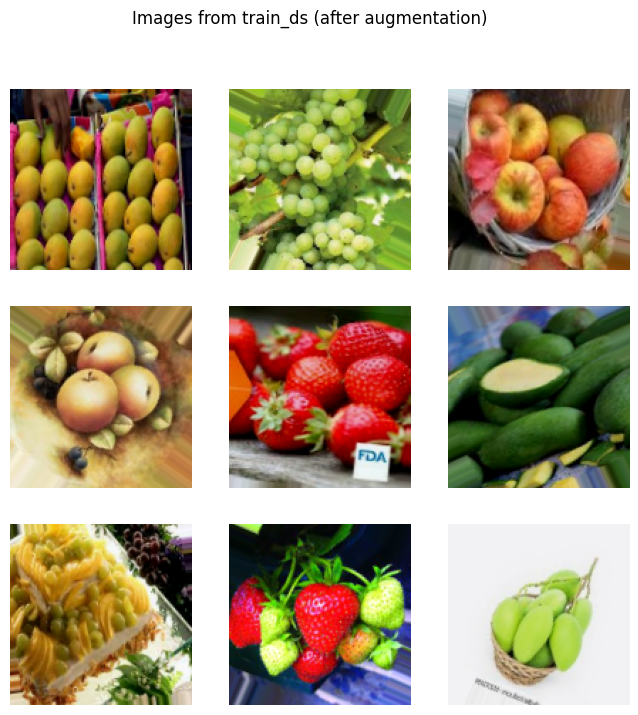

In [ ]:
import matplotlib.pyplot as plt
def denormalize(x):
    x = tf.clip_by_value(x, 0.0, 1.0)
    return tf.cast(x * 255.0, tf.uint8)

for images, labels in train_ds.take(1):
    plt.figure(figsize=(8, 8))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(denormalize(images[i]))
        plt.axis("off")
    plt.suptitle("Images from train_ds (after augmentation)")
    plt.show()


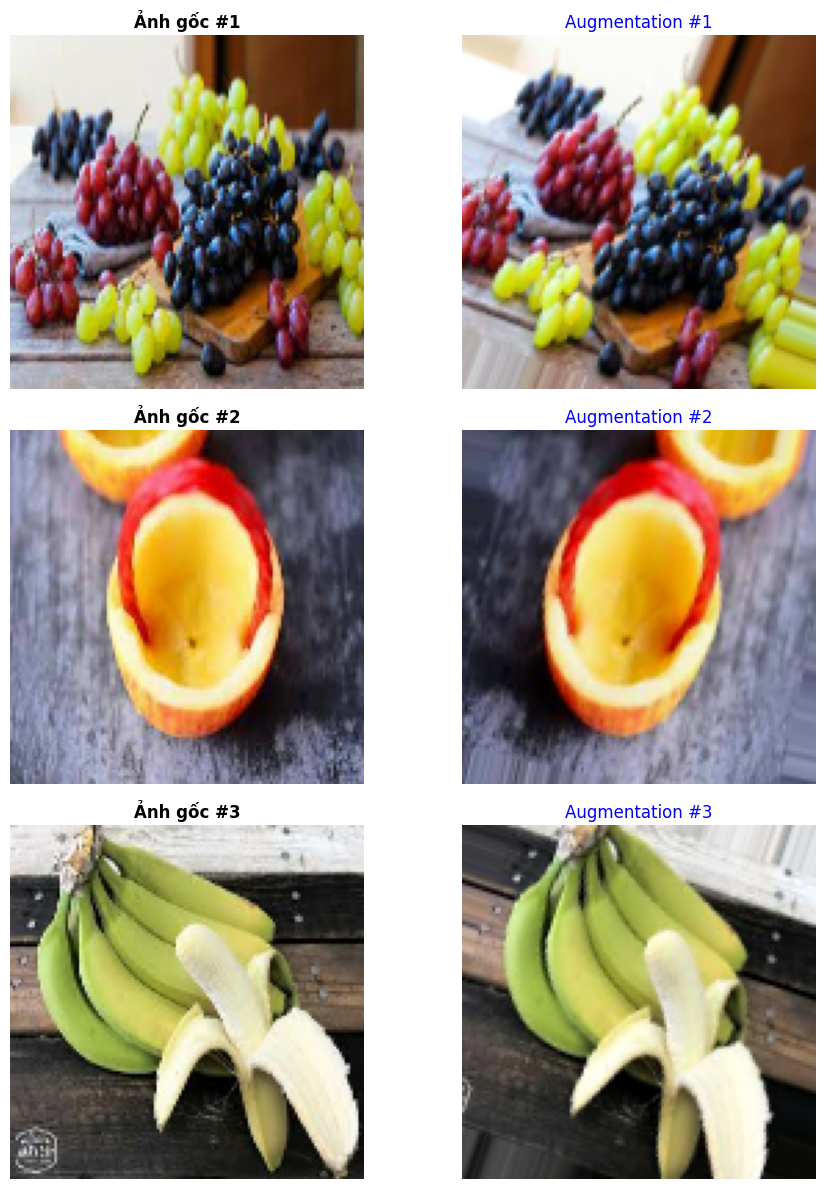

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf


for images, labels in train.take(1):

    fig, axes = plt.subplots(3, 2, figsize=(10, 12))
    for i in range(3):
        raw_image = images[i]

        # ẢNH GỐC
        ax_orig = axes[i, 0] # Lấy khung hình bên trái hàng i
        ax_orig.imshow(tf.cast(raw_image, tf.uint8))
        ax_orig.set_title(f"Ảnh gốc #{i+1}", fontsize=12, fontweight='bold')
        ax_orig.axis("off") # Tắt trục tọa độ cho sạch

        # Ảnh biến đổi
        input_tensor = tf.expand_dims(raw_image, axis=0)
        aug_tensor = data_augmentation(input_tensor, training=True)
        aug_image = aug_tensor[0]
        viz_image = tf.clip_by_value(aug_image, 0, 255)

        ax_aug = axes[i, 1]
        ax_aug.imshow(tf.cast(viz_image, tf.uint8))
        ax_aug.set_title(f"Augmentation #{i+1}", fontsize=12, color='blue')
        ax_aug.axis("off")

    plt.tight_layout()
    plt.show()
    break

# Định nghĩa mô hình

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten,
    Dropout, BatchNormalization
)

model = Sequential([
    # Conv Block 1
    Conv2D(16, (3, 3), padding='same', activation='relu',
           input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Conv Block 2
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Conv Block 3
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Conv Block 4
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Conv Block 5
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Classifier
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-4)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Xem tóm tắt mô hình
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,444,709 (5.51 MB)

 Trainable params: 1,443,717 (5.51 MB)

 Non-trainable params: 992 (3.88 KB)

# cấu hình train


In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from tensorflow.keras import layers, models


EPOCHS = 40
DATA_DIR = "/content/data_local/train"

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)


In [ ]:
import os
import tensorflow as tf

CHECKPOINT_DIR = "/content/drive/MyDrive/deeplearning pj/cnn_test_3"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "cnn3.keras")
LAST_EPOCH_PATH = os.path.join(CHECKPOINT_DIR, "last_epoch2.txt")

In [ ]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)
class EpochSaver(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        with open(LAST_EPOCH_PATH, "w") as f:
            f.write(str(epoch + 1))  # epoch bắt đầu từ 0


In [ ]:
def load_last_epoch():
    if os.path.exists(LAST_EPOCH_PATH):
        with open(LAST_EPOCH_PATH, "r") as f:
            return int(f.read())
    return 0


In [ ]:
if os.path.exists(BEST_MODEL_PATH):
    print("Loading saved model")
    model = tf.keras.models.load_model(BEST_MODEL_PATH)
    initial_epoch = load_last_epoch()
else:
    print("Training từ đầu")
    initial_epoch = 0


Loading saved model


#Tiến trình train

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    initial_epoch=initial_epoch,
    callbacks=[
        checkpoint_cb,
        early_stopping,
        EpochSaver()
    ]
)

Epoch 1/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3382 - loss: 2.0498
Epoch 1: val_loss improved from inf to 2.88073, saving model to /content/drive/MyDrive/deeplearning pj/cnn_test_3/cnn3.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 312s 1s/step - accuracy: 0.3385 - loss: 2.0480 - val_accuracy: 0.2060 - val_loss: 2.8807
Epoch 2/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4818 - loss: 1.2495
Epoch 2: val_loss improved from 2.88073 to 1.17209, saving model to /content/drive/MyDrive/deeplearning pj/cnn_test_3/cnn3.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 312s 1s/step - accuracy: 0.4818 - loss: 1.2494 - val_accuracy: 0.5160 - val_loss: 1.1721
Epoch 3/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5270 - loss: 1.1457
Epoch 3: val_loss improved from 1.17209 to 0.96837, saving model to /content/drive/MyDrive/deeplearning pj/cnn_test_3/cnn3.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 315s 1s/step - accuracy: 0.5270 - loss: 1.1456 - val_accuracy: 0.5940 - val_loss: 0.9684
Epoch 4/

# thử nghiệm trên tập test và trực quan kết qủa

In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/data_local/test",
    batch_size=BATCH_SIZE,
    image_size=(IMG_SIZE, IMG_SIZE),
    label_mode="categorical",
    shuffle=False
)

test_ds = test_ds.map(
    lambda x, y: (normalize_cnn(x), y),
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.prefetch(AUTOTUNE)

Found 1000 files belonging to 5 classes.


In [ ]:
if 'best_model' not in globals() or best_model is None:
    if 'BEST_MODEL_PATH' in globals() and os.path.exists(BEST_MODEL_PATH):
        best_model = tf.keras.models.load_model(BEST_MODEL_PATH)
    else:
        print("Không tìm thấy mô hình đã lưu")
        best_model = model

print("Đang đánh giá mô hình trên tập kiểm tra")
loss, accuracy = best_model.evaluate(test_ds)

print(f"Loss trên tập kiểm tra: {loss:.4f}")
print(f"Accuracy trên tập kiểm tra: {accuracy:.4f}")

Đang đánh giá mô hình trên tập kiểm tra...
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 362ms/step - accuracy: 0.6903 - loss: 0.8657
Loss trên tập kiểm tra: 0.6761
Accuracy trên tập kiểm tra: 0.7530


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# Get true labels and predictions from the test set
y_true_test = []
y_pred_probs_test = []

for images, labels in test_ds:
    y_true_test.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_probs_test.extend(best_model.predict(images))

y_pred_test = np.argmax(np.array(y_pred_probs_test), axis=1)


if 'class_names' not in globals() and hasattr(test_ds, 'class_names'):
    class_names = test_ds.class_names
elif 'class_names' not in globals() and hasattr(val_ds, 'class_names'):
    class_names = val_ds.class_names

print("\n--- Detailed Classification Report on Test Set ---")
print(classification_report(y_true_test, y_pred_test, target_names=class_names))

print(f"Overall Accuracy on Test Set: {accuracy_score(y_true_test, y_pred_test):.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

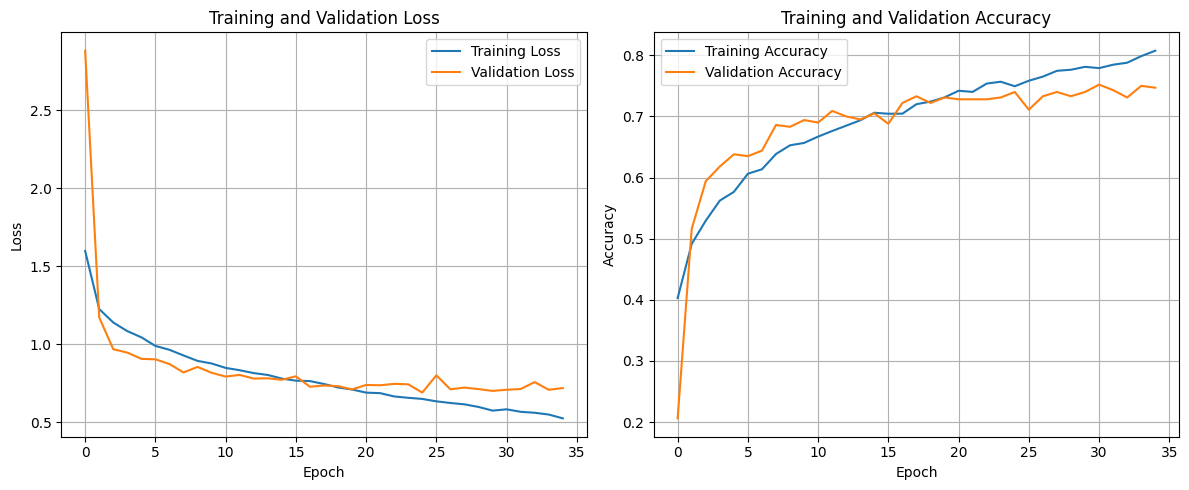

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

hist_df = pd.DataFrame(history.history)
hist_df.index.name = 'Epoch'

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_df['loss'], label='Training Loss')
plt.plot(hist_df['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(hist_df['accuracy'], label='Training Accuracy')
plt.plot(hist_df['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 858ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

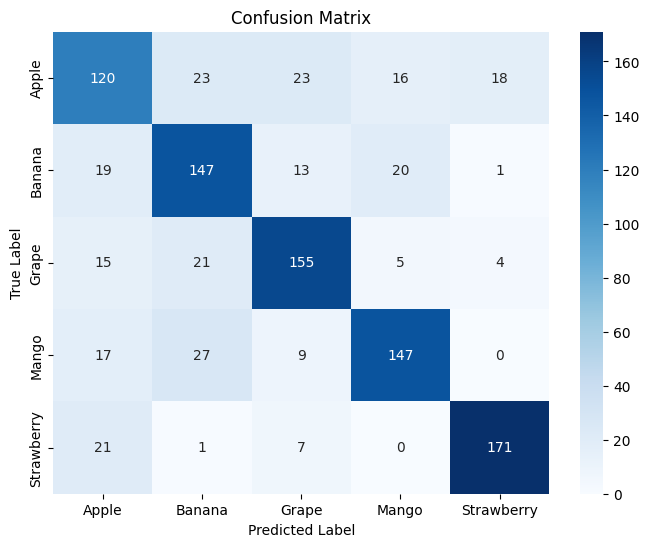

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Load the best model (if it was saved and early stopping occurred)
# If the model was not reloaded, this step is redundant but safe.
if 'BEST_MODEL_PATH' in globals() and os.path.exists(BEST_MODEL_PATH):
    best_model = tf.keras.models.load_model(BEST_MODEL_PATH)
else:
    best_model = model # Use the last trained model

# Get true labels and predictions from the validation set
y_true = []
y_pred_probs = []

for images, labels in val_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_probs.extend(best_model.predict(images))

y_pred = np.argmax(np.array(y_pred_probs), axis=1)

# Get class names from the validation dataset by creating a temporary dataset object
# The val_ds object itself is a _PrefetchDataset and does not have .class_names directly
temp_val_ds_for_names = tf.keras.utils.image_dataset_from_directory(
    "/content/data_local/valid",
    image_size=(IMG_SIZE, IMG_SIZE),
    label_mode="categorical",
    shuffle=False # Shuffle doesn't matter for class_names
)
class_names = temp_val_ds_for_names.class_names

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()